## AI Credit Risk & Financial Intelligence Platform

## 1. Environment Setup

## Data Audit and EDA

Data Source: German Credit dataset.
- setup and data loading
- structural review
- target balance and data quality
- numeric and categorical analysis
- advanced visual EDA
- business-facing risk summaries
- final findings and next actions


In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

project_root = Path.cwd().resolve().parents[0]
src_dir = project_root / "src"
if str(src_dir) not in sys.path:
    sys.path.insert(0, str(src_dir))

from credit_risk_platform.data.german_credit import (
    interim_german_credit_dir,
    raw_german_credit_dir,
    verify_statlog_extract,
)
from credit_risk_platform.utils.io import load_csv

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 13

risk_palette = {"good": "#1f77b4", "bad": "#d62728"}

print("project_root:", project_root)
print("src_dir exists:", src_dir.exists())


project_root: /Users/ememakpan/Documents/New project/applied_ai_economics_portfolio/project_01_ai_credit_risk_platform
src_dir exists: True


## 2. Verify Raw and Interim Data Paths

In [2]:
raw_summary = verify_statlog_extract(project_root)
raw_dir = raw_german_credit_dir(project_root)
interim_dir = interim_german_credit_dir(project_root)

print("Raw directory:", raw_dir)
print("Interim directory:", interim_dir)
raw_summary


Raw directory: /Users/ememakpan/Documents/New project/applied_ai_economics_portfolio/project_01_ai_credit_risk_platform/data/raw/statlog_german_credit
Interim directory: /Users/ememakpan/Documents/New project/applied_ai_economics_portfolio/project_01_ai_credit_risk_platform/data/interim/statlog_german_credit


{'raw_dir': '/Users/ememakpan/Documents/New project/applied_ai_economics_portfolio/project_01_ai_credit_risk_platform/data/raw/statlog_german_credit',
 'exists': True,
 'existing_files': ['Index',
  'german.data',
  'german.data-numeric',
  'german.doc'],
 'missing_files': [],
 'is_complete': True}

## 3. Load the Standardized Dataset

In [3]:
df = load_csv(interim_dir / "german_credit_standardized.csv")
df.head()


,applicant_id,checking_account_status,duration_months,credit_history,purpose,credit_amount,savings_account,employment_duration,installment_rate_pct_income,personal_status_sex,...,other_installment_plans,housing,existing_credits_count,job_type,liable_people_count,telephone,foreign_worker,risk_class,risk_label,TARGET
0,1,A11,6,A34,A43,1169,A65,A75,4,A93,...,A143,A152,2,A173,1,A192,A201,1,good,0
1,2,A12,48,A32,A43,5951,A61,A73,2,A92,...,A143,A152,1,A173,1,A191,A201,2,bad,1
2,3,A14,12,A34,A46,2096,A61,A74,2,A93,...,A143,A152,1,A172,2,A191,A201,1,good,0
3,4,A11,42,A32,A42,7882,A61,A74,2,A93,...,A143,A153,1,A173,2,A191,A201,1,good,0
4,5,A11,24,A33,A40,4870,A61,A73,3,A93,...,A143,A153,2,A173,2,A191,A201,2,bad,1


## 4. Review Dataset Structure

In [4]:
print("Shape:", df.shape)
display(pd.DataFrame({"column": df.columns, "dtype": df.dtypes.astype(str).values}))
df.info()


Shape: (1000, 24)


,column,dtype
0,applicant_id,int64
1,checking_account_status,object
2,duration_months,int64
3,credit_history,object
4,purpose,object
5,credit_amount,int64
6,savings_account,object
7,employment_duration,object
8,installment_rate_pct_income,int64
9,personal_status_sex,object


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 24 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   applicant_id                 1000 non-null   int64 
 1   checking_account_status      1000 non-null   object
 2   duration_months              1000 non-null   int64 
 3   credit_history               1000 non-null   object
 4   purpose                      1000 non-null   object
 5   credit_amount                1000 non-null   int64 
 6   savings_account              1000 non-null   object
 7   employment_duration          1000 non-null   object
 8   installment_rate_pct_income  1000 non-null   int64 
 9   personal_status_sex          1000 non-null   object
 10  other_debtors_guarantors     1000 non-null   object
 11  present_residence_years      1000 non-null   int64 
 12  property_type                1000 non-null   object
 13  age_years                    1000 

## 5. Review the Target Variable

In [5]:
target_counts = df["risk_label"].value_counts()
target_share = (df["risk_label"].value_counts(normalize=True) * 100).round(2)

display(target_counts.rename("count"))
display(target_share.rename("percentage"))


risk_label
good    700
bad     300
Name: count, dtype: int64

risk_label
good    70.0
bad     30.0
Name: percentage, dtype: float64

## 6. Assess Missingness and Duplicates

In [6]:
missing_counts = df.isna().sum().sort_values(ascending=False)
missing_pct = ((df.isna().sum() / len(df)) * 100).sort_values(ascending=False).round(2)

missing_table = pd.DataFrame({"missing_count": missing_counts, "missing_pct": missing_pct})
display(missing_table.query("missing_count > 0"))
print("Duplicate rows:", df.duplicated().sum())


,missing_count,missing_pct


Duplicate rows: 0


## 7. Review Numeric Features

In [7]:
numeric_cols = df.select_dtypes(include="number").columns.tolist()
print(numeric_cols)
display(df[numeric_cols].describe().T)


['applicant_id', 'duration_months', 'credit_amount', 'installment_rate_pct_income', 'present_residence_years', 'age_years', 'existing_credits_count', 'liable_people_count', 'risk_class', 'TARGET']


,count,mean,std,min,25%,50%,75%,max
applicant_id,1000.0,500.500,288.819436,1.0,250.75,500.5,750.25,1000.0
duration_months,1000.0,20.903,12.058814,4.0,12.00,18.0,24.00,72.0
credit_amount,1000.0,3271.258,2822.736876,250.0,1365.50,2319.5,3972.25,18424.0
installment_rate_pct_income,1000.0,2.973,1.118715,1.0,2.00,3.0,4.00,4.0
present_residence_years,1000.0,2.845,1.103718,1.0,2.00,3.0,4.00,4.0
age_years,1000.0,35.546,11.375469,19.0,27.00,33.0,42.00,75.0
existing_credits_count,1000.0,1.407,0.577654,1.0,1.00,1.0,2.00,4.0
liable_people_count,1000.0,1.155,0.362086,1.0,1.00,1.0,1.00,2.0
risk_class,1000.0,1.300,0.458487,1.0,1.00,1.0,2.00,2.0
TARGET,1000.0,0.300,0.458487,0.0,0.00,0.0,1.00,1.0


## 8. Review Categorical Features

In [8]:
categorical_cols = df.select_dtypes(exclude="number").columns.tolist()
print(categorical_cols)

for col in categorical_cols:
    print(f"\n--- {col} ---")
    display(df[col].value_counts(dropna=False).rename("count").to_frame())


['checking_account_status', 'credit_history', 'purpose', 'savings_account', 'employment_duration', 'personal_status_sex', 'other_debtors_guarantors', 'property_type', 'other_installment_plans', 'housing', 'job_type', 'telephone', 'foreign_worker', 'risk_label']

--- checking_account_status ---


,count
checking_account_status,
A14,394
A11,274
A12,269
A13,63



--- credit_history ---


,count
credit_history,
A32,530
A34,293
A33,88
A31,49
A30,40



--- purpose ---


...

,count
telephone,
A191,596
A192,404



--- foreign_worker ---


,count
foreign_worker,
A201,963
A202,37



--- risk_label ---


,count
risk_label,
good,700
bad,300


## 9. Visualise Target Distribution

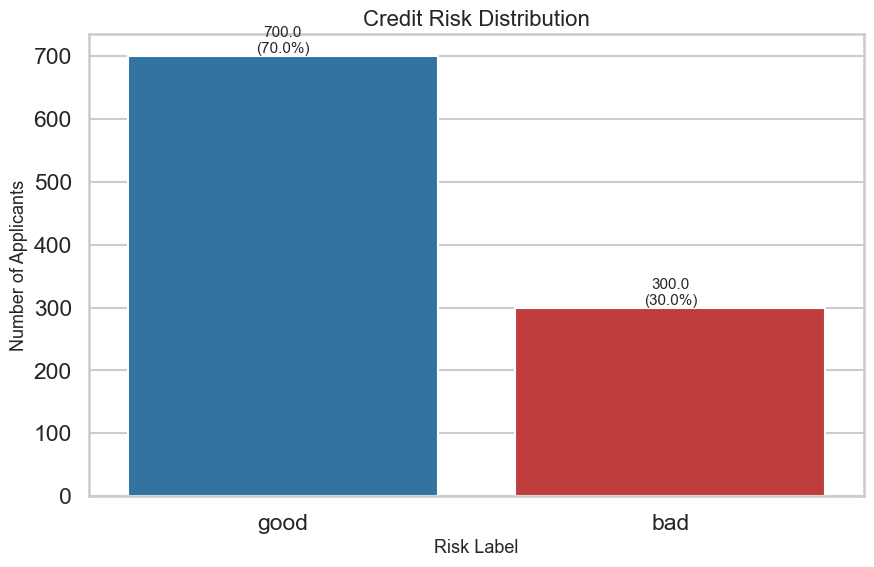

In [9]:
ax = sns.countplot(data=df, x="risk_label", hue="risk_label", palette=risk_palette, legend=False)

total = len(df)
for p in ax.patches:
    height = p.get_height()
    ax.annotate(
        f"{height}\n({height/total:.1%})",
        (p.get_x() + p.get_width() / 2, height),
        ha="center",
        va="bottom",
        fontsize=11,
    )

plt.title("Credit Risk Distribution")
plt.xlabel("Risk Label")
plt.ylabel("Number of Applicants")
plt.show()


## 10. Compare Key Numeric Variables by Risk

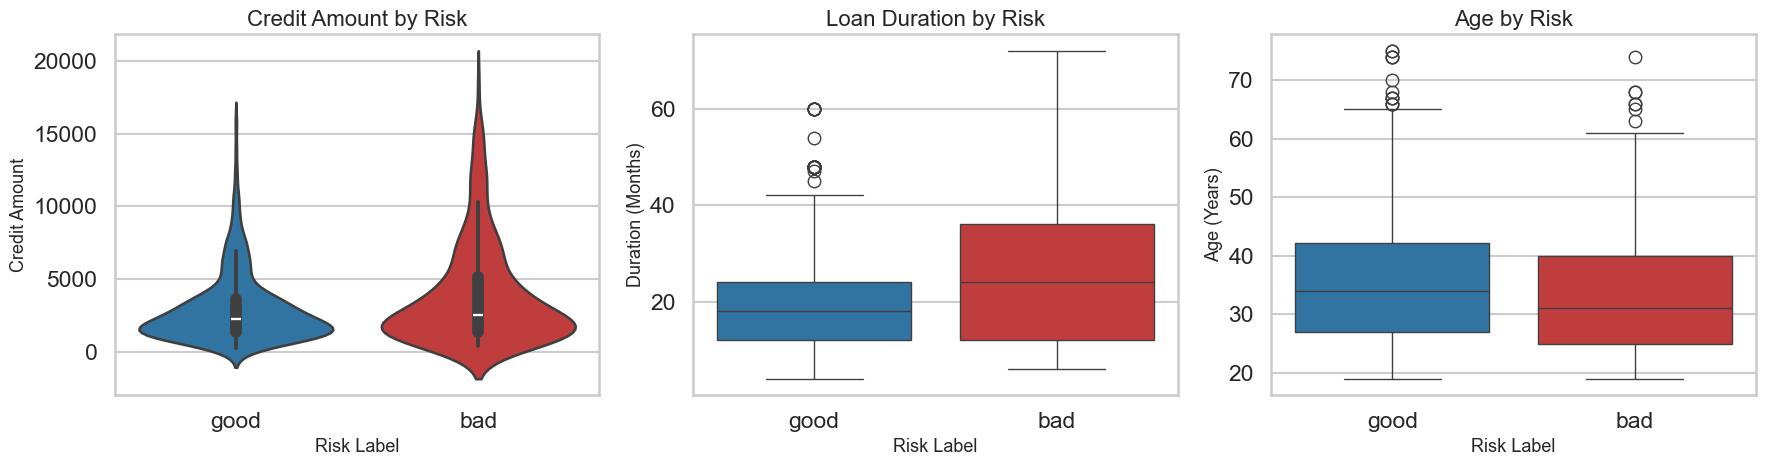

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.violinplot(data=df, x="risk_label", y="credit_amount", hue="risk_label", palette=risk_palette, legend=False, ax=axes[0])
axes[0].set_title("Credit Amount by Risk")
axes[0].set_xlabel("Risk Label")
axes[0].set_ylabel("Credit Amount")

sns.boxplot(data=df, x="risk_label", y="duration_months", hue="risk_label", palette=risk_palette, legend=False, ax=axes[1])
axes[1].set_title("Loan Duration by Risk")
axes[1].set_xlabel("Risk Label")
axes[1].set_ylabel("Duration (Months)")

sns.boxplot(data=df, x="risk_label", y="age_years", hue="risk_label", palette=risk_palette, legend=False, ax=axes[2])
axes[2].set_title("Age by Risk")
axes[2].set_xlabel("Risk Label")
axes[2].set_ylabel("Age (Years)")

plt.tight_layout()
plt.show()


## 11. Inspect Numeric Distributions and Outlier Signals

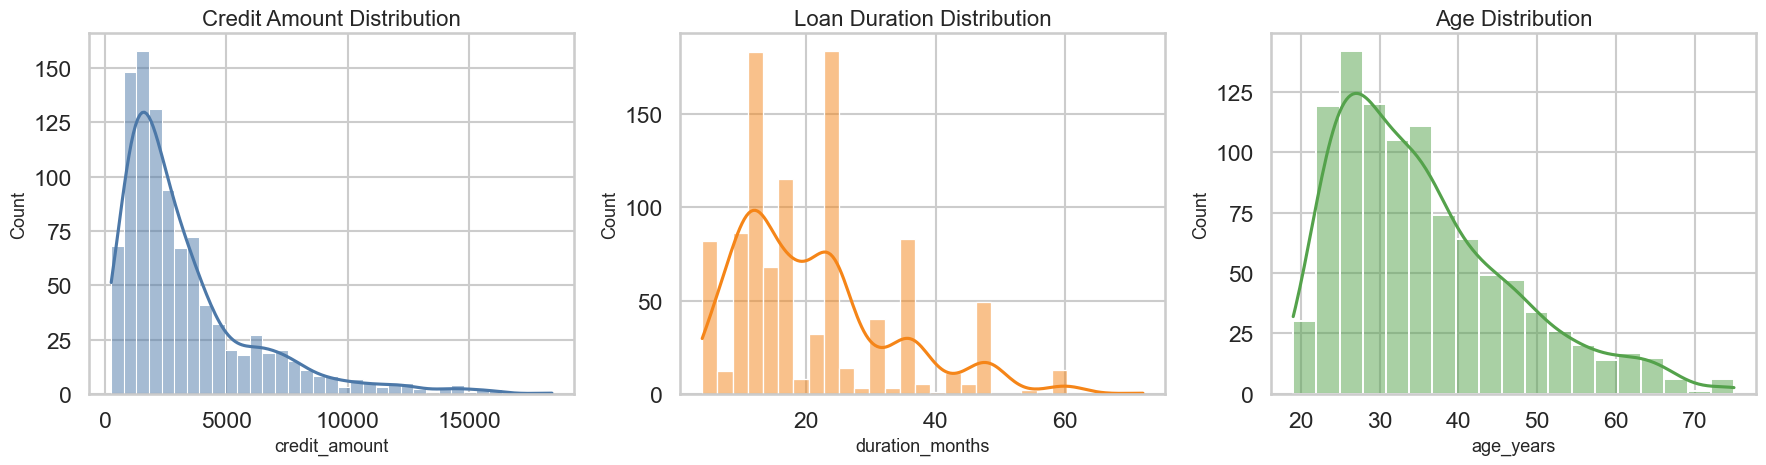

,0.01,0.05,0.50,0.95,0.99
credit_amount,425.83,708.95,2319.5,9162.7,14180.39
duration_months,6.00,6.00,18.0,48.0,60.00
age_years,20.00,22.00,33.0,60.0,67.01


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df["credit_amount"], kde=True, color="#4c78a8", ax=axes[0])
axes[0].set_title("Credit Amount Distribution")

sns.histplot(df["duration_months"], kde=True, color="#f58518", ax=axes[1])
axes[1].set_title("Loan Duration Distribution")

sns.histplot(df["age_years"], kde=True, color="#54a24b", ax=axes[2])
axes[2].set_title("Age Distribution")

plt.tight_layout()
plt.show()

display(df[["credit_amount", "duration_months", "age_years"]].quantile([0.01, 0.05, 0.50, 0.95, 0.99]).T)


### Outlier Interpretation

The numeric distributions show that `credit_amount` and `duration_months` are positively skewed with long right tails, indicating the presence of high-value observations. These appear more likely to represent genuine high-risk lending cases than data-entry errors. `age_years` shows a milder tail and fewer extreme observations.

At this stage, the outliers should be retained for analysis. In preprocessing, `credit_amount` may benefit from log transformation or capping, while `duration_months` should be reviewed as a potential risk signal rather than automatically removed.


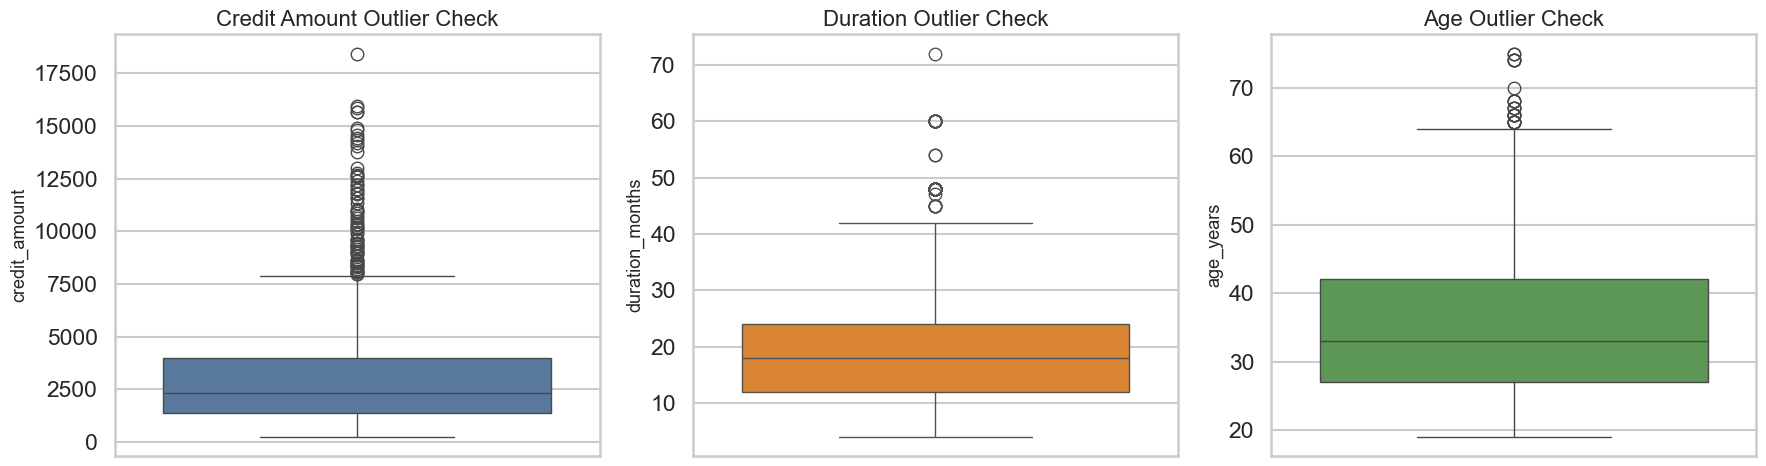

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(data=df, y="credit_amount", color="#4c78a8", ax=axes[0])
axes[0].set_title("Credit Amount Outlier Check")

sns.boxplot(data=df, y="duration_months", color="#f58518", ax=axes[1])
axes[1].set_title("Duration Outlier Check")

sns.boxplot(data=df, y="age_years", color="#54a24b", ax=axes[2])
axes[2].set_title("Age Outlier Check")

plt.tight_layout()
plt.show()


### Outlier Findings

The boxplots confirm clear upper-tail outliers in `credit_amount` and `duration_months`. These observations are likely to reflect genuine higher-risk lending cases rather than invalid records, so they should not be removed at the EDA stage.

`age_years` shows only a small number of mild upper-tail outliers. Compared with the financial variables, age appears less problematic from an outlier perspective.

The current evidence suggests that later preprocessing should focus on transformation or capping for `credit_amount`, careful treatment of `duration_months`, and minimal intervention for `age_years`.


## 12. Build Business-Facing Bad-Rate Views

In [12]:
def bad_rate_table(feature_name: str) -> pd.DataFrame:
    return (
        pd.crosstab(df[feature_name], df["risk_label"], normalize="index")
        .round(3)
        .reset_index()
        .sort_values("bad", ascending=False)
    )

checking_plot = bad_rate_table("checking_account_status")
savings_plot = bad_rate_table("savings_account")
housing_plot = bad_rate_table("housing")
credit_history_plot = bad_rate_table("credit_history")

display(checking_plot)
display(savings_plot)
display(housing_plot)
display(credit_history_plot)


risk_label,checking_account_status,bad,good
0,A11,0.493,0.507
1,A12,0.390,0.610
2,A13,0.222,0.778
3,A14,0.117,0.883


risk_label,savings_account,bad,good
0,A61,0.360,0.640
1,A62,0.330,0.670
2,A63,0.175,0.825
4,A65,0.175,0.825
3,A64,0.125,0.875


risk_label,housing,bad,good
2,A153,0.407,0.593
0,A151,0.391,0.609
1,A152,0.261,0.739


risk_label,credit_history,bad,good
0,A30,0.625,0.375
1,A31,0.571,0.429
2,A32,0.319,0.681
3,A33,0.318,0.682
4,A34,0.171,0.829


## 13. Visualise Bad Rate by Key Categories

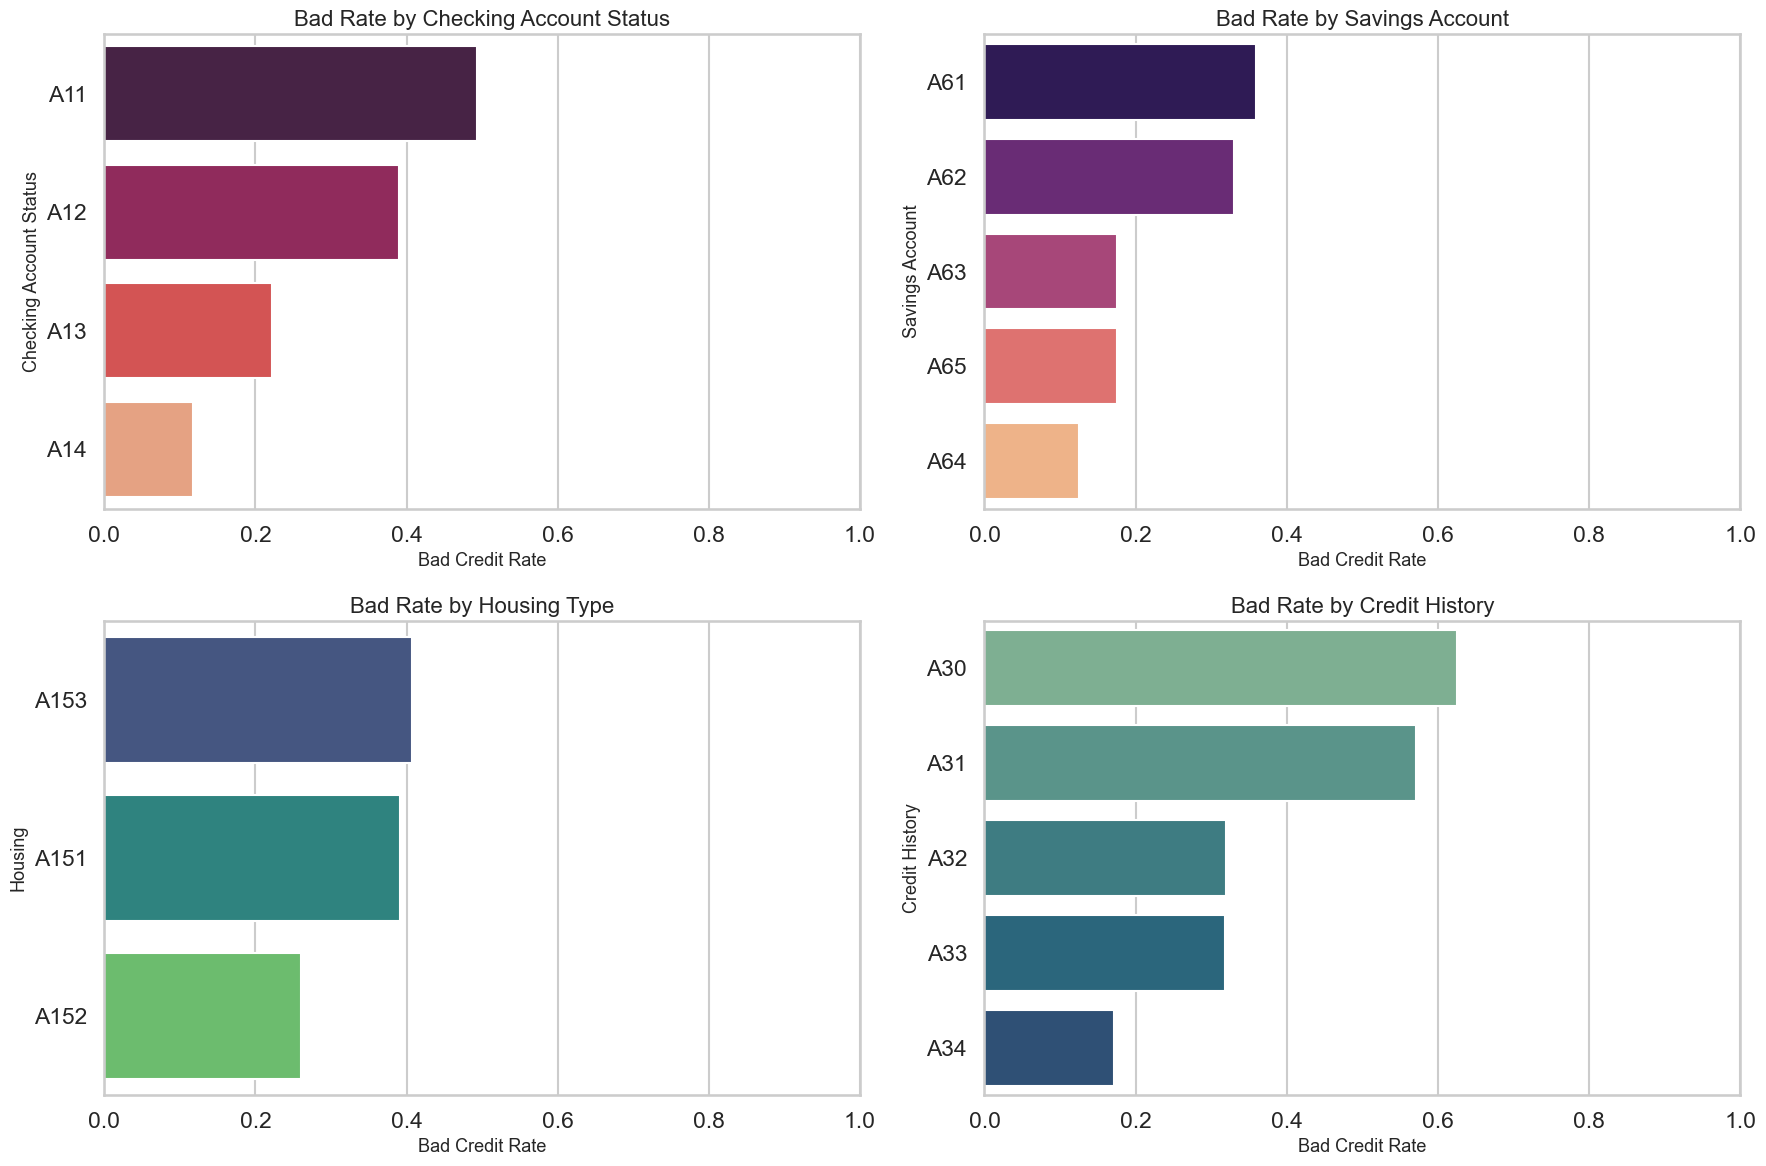

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

sns.barplot(data=checking_plot, x="bad", y="checking_account_status", hue="checking_account_status", palette="rocket", legend=False, ax=axes[0, 0])
axes[0, 0].set_title("Bad Rate by Checking Account Status")
axes[0, 0].set_xlim(0, 1)
axes[0, 0].set_xlabel("Bad Credit Rate")
axes[0, 0].set_ylabel("Checking Account Status")

sns.barplot(data=savings_plot, x="bad", y="savings_account", hue="savings_account", palette="magma", legend=False, ax=axes[0, 1])
axes[0, 1].set_title("Bad Rate by Savings Account")
axes[0, 1].set_xlim(0, 1)
axes[0, 1].set_xlabel("Bad Credit Rate")
axes[0, 1].set_ylabel("Savings Account")

sns.barplot(data=housing_plot, x="bad", y="housing", hue="housing", palette="viridis", legend=False, ax=axes[1, 0])
axes[1, 0].set_title("Bad Rate by Housing Type")
axes[1, 0].set_xlim(0, 1)
axes[1, 0].set_xlabel("Bad Credit Rate")
axes[1, 0].set_ylabel("Housing")

sns.barplot(data=credit_history_plot, x="bad", y="credit_history", hue="credit_history", palette="crest", legend=False, ax=axes[1, 1])
axes[1, 1].set_title("Bad Rate by Credit History")
axes[1, 1].set_xlim(0, 1)
axes[1, 1].set_xlabel("Bad Credit Rate")
axes[1, 1].set_ylabel("Credit History")

plt.tight_layout()
plt.show()


## 14. Explore Two-Way Risk Interaction

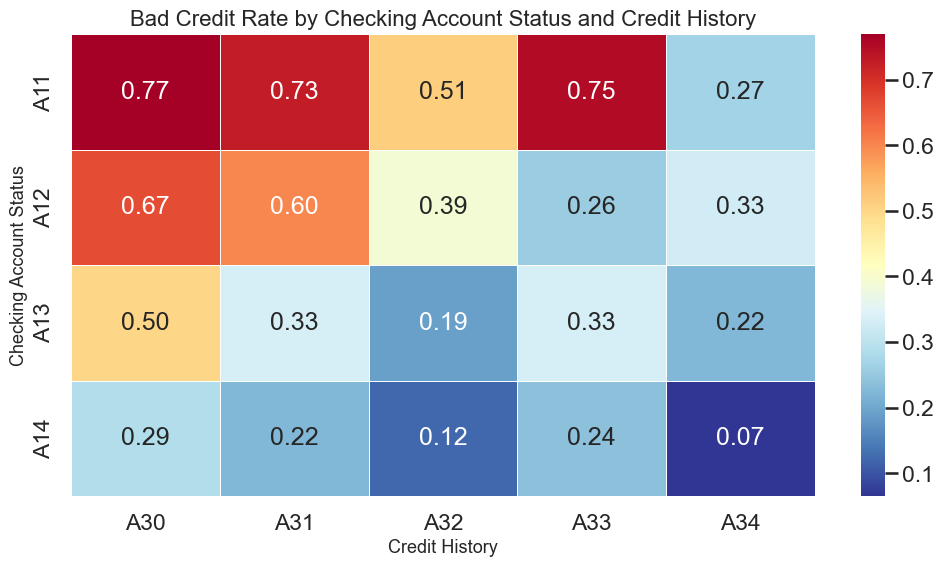

In [14]:
bad_rate_matrix = pd.crosstab(
    index=df["checking_account_status"],
    columns=df["credit_history"],
    values=df["TARGET"],
    aggfunc="mean",
)

plt.figure(figsize=(12, 6))
sns.heatmap(bad_rate_matrix, annot=True, fmt=".2f", cmap="RdYlBu_r", linewidths=0.5)
plt.title("Bad Credit Rate by Checking Account Status and Credit History")
plt.xlabel("Credit History")
plt.ylabel("Checking Account Status")
plt.show()


## Final Interpretation


## EDA Findings

### Dataset Structure
The standardized German Credit dataset contains 1,000 observations and 24 columns. The target variable is `TARGET`, where `1` represents bad credit risk and `0` represents good credit risk.

### Target Balance
The dataset is moderately imbalanced, with good credit cases forming the majority and bad credit cases forming the minority class. This is important for later modeling because evaluation should not rely only on accuracy.

### Data Quality
No major missing-data problem was identified in the standardized dataset, and duplicate records should be reviewed but do not appear to dominate the dataset. The main data-quality focus is therefore not missingness, but proper handling of categorical variables, skewed numeric features, and potential outliers.

### Numeric Feature Patterns
`credit_amount` and `duration_months` are clearly right-skewed and contain upper-tail outliers. These observations are likely to be genuine high-risk cases rather than obvious data errors, so they should be retained at this stage. `age_years` shows a much milder outlier pattern and is less concerning.

### Categorical Risk Signals
Early bad-rate analysis suggests that checking account status, savings account status, housing type, and credit history all carry meaningful risk information. These variables should be retained for downstream preprocessing and feature engineering.

### Outlier Assessment
Boxplots and distribution plots confirm that `credit_amount` and `duration_months` are the most outlier-sensitive variables in the dataset. These should be reviewed in preprocessing for possible transformation, capping, or robust modeling treatment rather than immediate removal.

### Conclusion
The dataset is suitable for credit risk modeling and shows clear early business signals. The next stage should focus on cleaning decisions, split strategy, categorical encoding choices, and preprocessing design before model training.
